--- Getting Started: Data Loading ---
Data loaded and frequency enforced.

--- Step 1: STL Decomposition ---


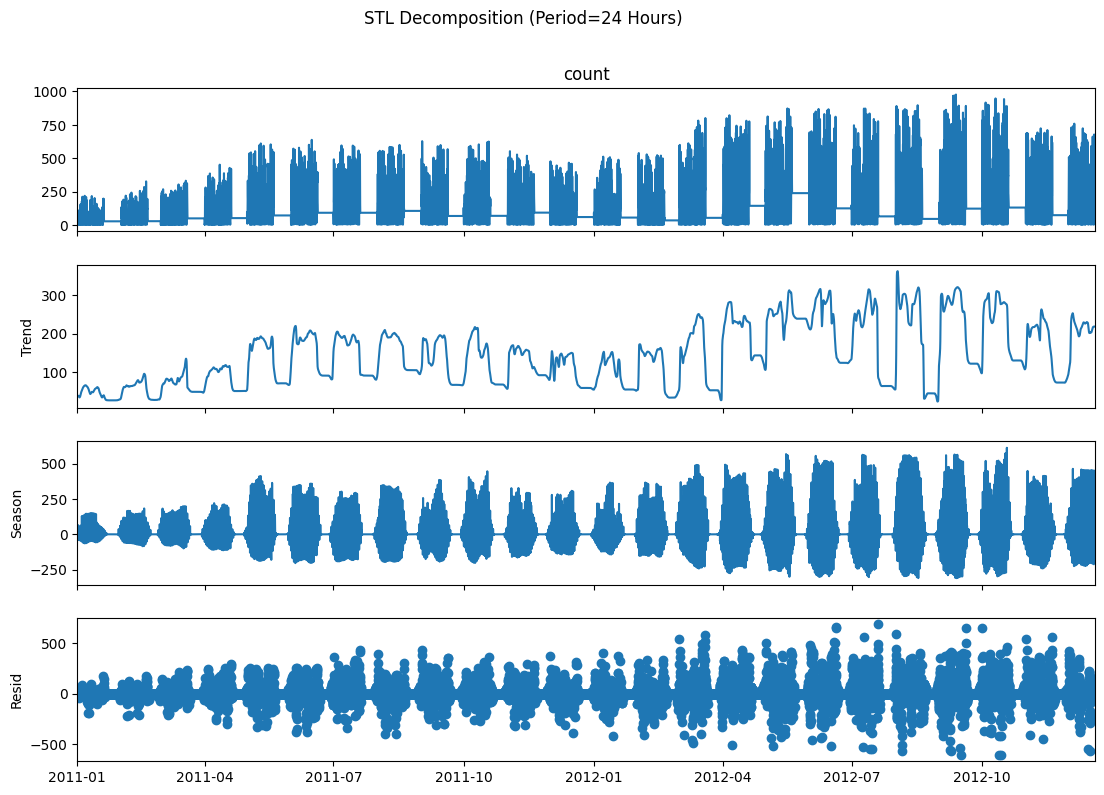


--- Step 2: Variance Stabilization ---


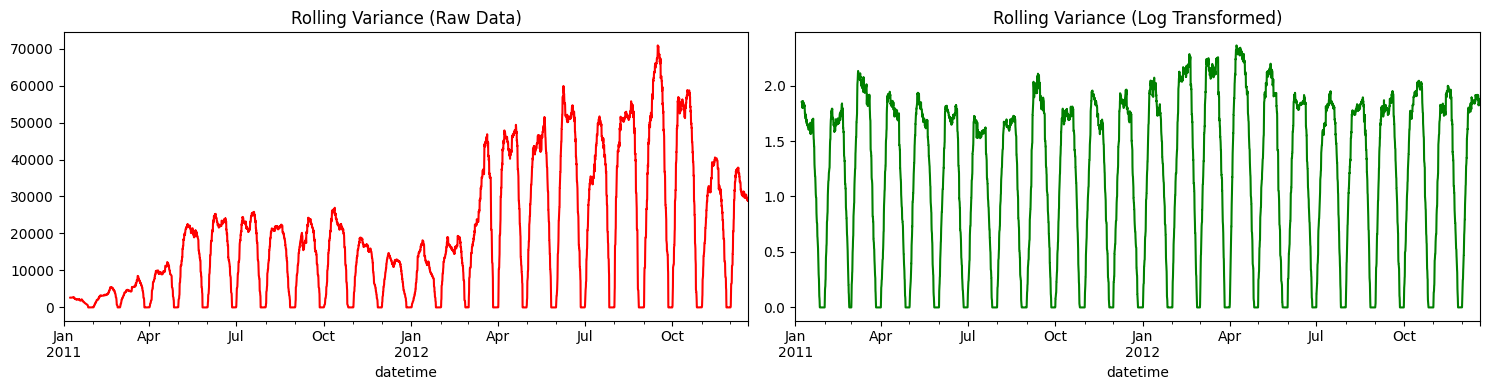


--- Step 3: Mean Stabilization (Differencing) ---


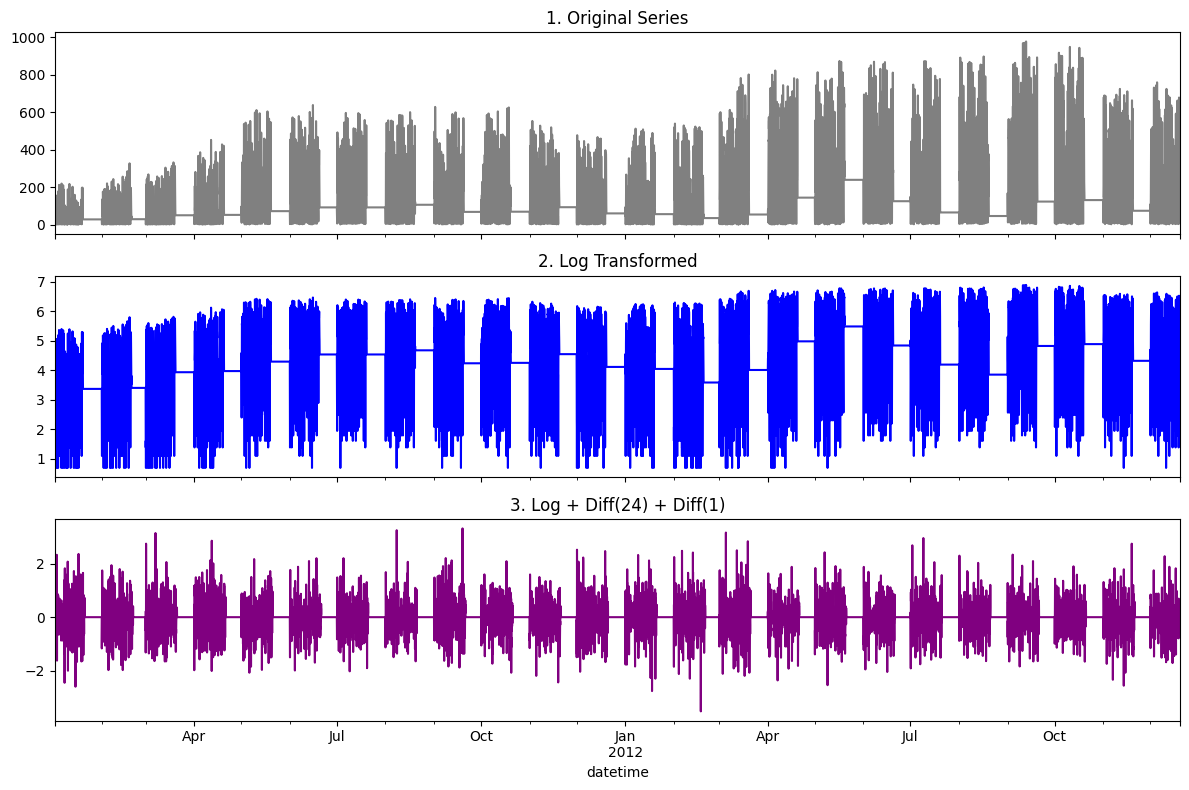


--- Step 4: Augmented Dickey-Fuller (ADF) Test ---
Testing: Raw Series
  ADF Statistic: -6.2892
  p-value:       0.0000
  Conclusion:    Stationary (Reject null hypothesis) ✅

Testing: Log Series
  ADF Statistic: -6.3867
  p-value:       0.0000
  Conclusion:    Stationary (Reject null hypothesis) ✅

Testing: Log + Diff(24) + Diff(1) Series
  ADF Statistic: -30.1727
  p-value:       0.0000
  Conclusion:    Stationary (Reject null hypothesis) ✅



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Getting Started: Reloading the Data
# ==========================================
print("--- Getting Started: Data Loading ---")
if not os.path.exists("train.csv"):
    raise FileNotFoundError("🛑 STOP! I cannot find 'train.csv'. Please make sure it is in the same folder.")

df = pd.read_csv("train.csv", parse_dates=["datetime"])
serie = df.set_index("datetime")["count"].sort_index()
serie = serie.asfreq("h").ffill()
print("Data loaded and frequency enforced.")

# ==========================================
# Step 1: STL Decomposition
# ==========================================
print("\n--- Step 1: STL Decomposition ---")
# period=24 because our strongest daily cycle repeats every 24 hours
stl = STL(serie, period=24, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition (Period=24 Hours)", y=1.02)
plt.show()

# ==========================================
# Step 2: Variance Stabilization (Log Transform)
# ==========================================
print("\n--- Step 2: Variance Stabilization ---")
# Calculate rolling variance over a 1-week window (24 hours * 7 days)
rolling_var_raw = serie.rolling(24 * 7).var()

# Apply Log transformation: np.log(serie + 1) handles zeros safely
serie_log = np.log(serie + 1)
rolling_var_log = serie_log.rolling(24 * 7).var()

# Plot to compare variances
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
rolling_var_raw.plot(ax=axes[0], color='red', title="Rolling Variance (Raw Data)")
rolling_var_log.plot(ax=axes[1], color='green', title="Rolling Variance (Log Transformed)")
plt.tight_layout()
plt.show()

# ==========================================
# Step 3: Mean Stabilization (Differencing)
# ==========================================
print("\n--- Step 3: Mean Stabilization (Differencing) ---")
# 1. Remove daily seasonality (Difference of 24 hours)
serie_diff24 = serie_log.diff(24).dropna()

# 2. Remove remaining trend (Difference of 1 hour)
serie_diff24_1 = serie_diff24.diff(1).dropna()

# Plot the progression
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
serie.plot(ax=axes[0], title="1. Original Series", color='gray')
serie_log.plot(ax=axes[1], title="2. Log Transformed", color='blue')
serie_diff24_1.plot(ax=axes[2], title="3. Log + Diff(24) + Diff(1)", color='purple')
plt.tight_layout()
plt.show()

# ==========================================
# Step 4: Statistical Testing (ADF Test)
# ==========================================
print("\n--- Step 4: Augmented Dickey-Fuller (ADF) Test ---")

def run_adf_test(timeseries, name):
    print(f"Testing: {name}")
    # Run the test
    result = adfuller(timeseries, autolag='AIC')
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    if result[1] <= 0.05:
        print("  Conclusion:    Stationary (Reject null hypothesis) ✅\n")
    else:
        print("  Conclusion:    Non-Stationary (Fail to reject null hypothesis) ❌\n")

# Run tests on the raw and transformed series
run_adf_test(serie, "Raw Series")
run_adf_test(serie_log, "Log Series")
run_adf_test(serie_diff24_1, "Log + Diff(24) + Diff(1) Series")